El data set que me toco, trata de ka venta de propiedades en Ecuador

Al leer el data set me salio el error de "UTF8", para resolverlo añadi "encoding="ISO-8859-1"

In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

In [3]:
#Leemos el data
data = pd.read_csv('/content/datos.csv', encoding="ISO-8859-1")
print(data)
data.info()

    Tipo de Propiedad           Sector Total construido        Precio  \
0        Departamento             Same           160 m²    USD160.000   
1                Casa        El Bosque           960 m²    USD800.000   
2                Casa          Cumbayá           275 m²    USD360.000   
3             Terreno            Checa              NaN    USD275.000   
4                Casa          Cumbayá          1740 m²    USD850.000   
..                ...              ...              ...           ...   
201           Terreno           Puembo              NaN    USD320.000   
202           Terreno  Centro de Manta              NaN  USD1.351.993   
203           Terreno     Centro Norte              NaN    USD600.000   
204           Terreno          Tumbaco              NaN    USD231.000   
205           Terreno  Centro de Manta              NaN    USD777.855   

                           Referencia  Dormitorios  Baños  Antiguedad  \
0               El Muelle, Esmeraldas          3.0

In [4]:
#variables categorias
#Objetos
columnas_categorias= data.select_dtypes(include=['object']).columns
#fechas
columnas_fecha= data.select_dtypes(include=['datetime64']).columns

In [5]:
#procesamiento de frases o palabras a numeros
for columna in columnas_categorias:
  le=LabelEncoder()
  data[columna]=le.fit_transform(data[columna])

In [6]:
#Procesamiento de fechas a numeros
for columna in columnas_fecha:
  data[columna]=pd.to_numeric(data[columna].map(datetime.timestamp))

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Tipo de Propiedad  206 non-null    int64  
 1   Sector             206 non-null    int64  
 2   Total construido   206 non-null    int64  
 3   Precio             206 non-null    int64  
 4   Referencia         206 non-null    int64  
 5   Dormitorios        121 non-null    float64
 6   Baños              126 non-null    float64
 7   Antiguedad         206 non-null    int64  
 8   Superficie         206 non-null    int64  
 9   Ambientes          108 non-null    float64
 10  24 Hours Security  206 non-null    int64  
 11  Alcantarillado     206 non-null    int64  
 12  Parqueadero fijo   206 non-null    int64  
 13  Seguridad 24Hs     206 non-null    int64  
 14  Expensas           7 non-null      float64
 15  Fecha de entrega   206 non-null    int64  
 16  Fecha              206 non

In [8]:
#llenar datos Vacios
columnas_especificas= ['Dormitorios','Baños','Ambientes','Expensas']
media_columnas=data[columnas_especificas].mean()
data[columnas_especificas]= data[columnas_especificas].fillna(media_columnas)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Tipo de Propiedad  206 non-null    int64  
 1   Sector             206 non-null    int64  
 2   Total construido   206 non-null    int64  
 3   Precio             206 non-null    int64  
 4   Referencia         206 non-null    int64  
 5   Dormitorios        206 non-null    float64
 6   Baños              206 non-null    float64
 7   Antiguedad         206 non-null    int64  
 8   Superficie         206 non-null    int64  
 9   Ambientes          206 non-null    float64
 10  24 Hours Security  206 non-null    int64  
 11  Alcantarillado     206 non-null    int64  
 12  Parqueadero fijo   206 non-null    int64  
 13  Seguridad 24Hs     206 non-null    int64  
 14  Expensas           206 non-null    float64
 15  Fecha de entrega   206 non-null    int64  
 16  Fecha              206 non

In [10]:
#Eliminamos la columna de 24 hours Security y Fecha
columnas_eliminadas= ['24 Hours Security','Fecha']
data.drop(columnas_eliminadas, axis=1, inplace=True)
#movemos la columna precio hacia el final
columna_a_mover= data.pop('Precio')
data['Precio']=columna_a_mover
nuevo_dataset = data.copy()
nuevo_dataset.to_csv('datos2.csv', index=False)
print("archivo creado exitosamente")

archivo creado exitosamente


In [11]:
#Leemos nuevamente el data set
data = pd.read_csv('/content/datos2.csv', encoding="ISO-8859-1")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Tipo de Propiedad  206 non-null    int64  
 1   Sector             206 non-null    int64  
 2   Total construido   206 non-null    int64  
 3   Referencia         206 non-null    int64  
 4   Dormitorios        206 non-null    float64
 5   BaÃ±os             206 non-null    float64
 6   Antiguedad         206 non-null    int64  
 7   Superficie         206 non-null    int64  
 8   Ambientes          206 non-null    float64
 9   Alcantarillado     206 non-null    int64  
 10  Parqueadero fijo   206 non-null    int64  
 11  Seguridad 24Hs     206 non-null    int64  
 12  Expensas           206 non-null    float64
 13  Fecha de entrega   206 non-null    int64  
 14  Precio             206 non-null    int64  
dtypes: float64(4), int64(11)
memory usage: 24.3 KB


In [12]:
# Lectura de Datos
X = data.iloc[:, :14]
y = data.iloc[:, 14]
m = y.size


print(X)
print('*'*25)
print(y)

     Tipo de Propiedad  Sector  Total construido  Referencia  Dormitorios  \
0                    1      28                26          37     3.000000   
1                    0      12               104         100     5.000000   
2                    0      11                62          31     3.000000   
3                    6      10               105          18     3.173554   
4                    0      11                34         106     4.000000   
..                 ...     ...               ...         ...          ...   
201                  6      26               105          68     3.173554   
202                  6       7               105           5     3.173554   
203                  6       5               105          81     3.173554   
204                  6      31               105         107     3.173554   
205                  6       7               105           6     3.173554   

       BaÃ±os  Antiguedad  Superficie  Ambientes  Alcantarillado  \
0    2.

In [13]:
# Normaliza entre -0.5 y 0.5
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma



In [14]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

     Tipo de Propiedad  Sector  Total construido  Referencia  Dormitorios  \
0                    1      28                26          37     3.000000   
1                    0      12               104         100     5.000000   
2                    0      11                62          31     3.000000   
3                    6      10               105          18     3.173554   
4                    0      11                34         106     4.000000   
..                 ...     ...               ...         ...          ...   
201                  6      26               105          68     3.173554   
202                  6       7               105           5     3.173554   
203                  6       5               105          81     3.173554   
204                  6      31               105         107     3.173554   
205                  6       7               105           6     3.173554   

       BaÃ±os  Antiguedad  Superficie  Ambientes  Alcantarillado  \
0    2.

In [15]:
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(X)

[[ 1.         -0.62434534  1.14343504 ...  0.21374115  0.
   0.14071951]
 [ 1.         -0.9960654  -0.66499197 ...  0.21374115  0.
   0.14071951]
 [ 1.         -0.9960654  -0.77801866 ...  0.21374115  0.
   0.14071951]
 ...
 [ 1.          1.23425496 -1.45617879 ...  0.21374115  0.
   0.14071951]
 [ 1.          1.23425496  1.48251511 ...  0.21374115  0.
   0.14071951]
 [ 1.          1.23425496 -1.23012541 ...  0.21374115  0.
   0.14071951]]


DESCENSO POR EL GRADIENTE


In [16]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [17]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [69.06836003 -0.6888877  -6.20930666  5.5108062   6.52166958 10.0608136
 -0.68648157 -2.4287119  -4.44661636 -3.10657308 -1.10093494 -3.3463677
  3.2960478   0.49486303  1.4682975 ]
El valor predecido es (usando el descenso por el gradiente): 6498.4482


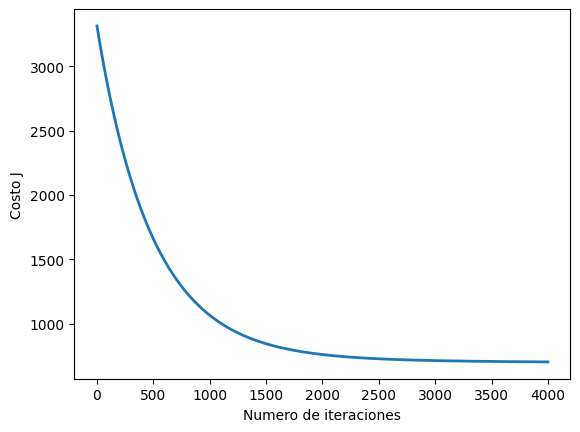

In [21]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 4000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(15)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el precio para Propiedades en el Ecuador con distintas caracteristicas
X_array = [6,31,100,120,4,5,30,200,5,2,2,3,500,1,20]
X_array[1:15] = (X_array[1:15] - mu) / sigma
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('El valor predecido es (usando el descenso por el gradiente): {:.4f}'.format(price))

In [23]:
X_array = [6,31,100,120,4,5,30,200,5,2,2,3,500,1,20]
X_array[1:15] = (X_array[1:15] - mu) / sigma

In [24]:
X_array[1:15]
print(np.dot(X_array, theta))

6498.448240783642


ECUACION DE LA NORMAL

In [25]:
data = pd.read_csv('/content/datos2.csv', encoding="ISO-8859-1")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Tipo de Propiedad  206 non-null    int64  
 1   Sector             206 non-null    int64  
 2   Total construido   206 non-null    int64  
 3   Referencia         206 non-null    int64  
 4   Dormitorios        206 non-null    float64
 5   BaÃ±os             206 non-null    float64
 6   Antiguedad         206 non-null    int64  
 7   Superficie         206 non-null    int64  
 8   Ambientes          206 non-null    float64
 9   Alcantarillado     206 non-null    int64  
 10  Parqueadero fijo   206 non-null    int64  
 11  Seguridad 24Hs     206 non-null    int64  
 12  Expensas           206 non-null    float64
 13  Fecha de entrega   206 non-null    int64  
 14  Precio             206 non-null    int64  
dtypes: float64(4), int64(11)
memory usage: 24.3 KB


In [26]:
# Lectura de Datos
X = data.iloc[:, :14]
y = data.iloc[:, 14]
m = y.size

print(X)
print('*'*25)
print(y)

     Tipo de Propiedad  Sector  Total construido  Referencia  Dormitorios  \
0                    1      28                26          37     3.000000   
1                    0      12               104         100     5.000000   
2                    0      11                62          31     3.000000   
3                    6      10               105          18     3.173554   
4                    0      11                34         106     4.000000   
..                 ...     ...               ...         ...          ...   
201                  6      26               105          68     3.173554   
202                  6       7               105           5     3.173554   
203                  6       5               105          81     3.173554   
204                  6      31               105         107     3.173554   
205                  6       7               105           6     3.173554   

       BaÃ±os  Antiguedad  Superficie  Ambientes  Alcantarillado  \
0    2.

In [27]:
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [28]:
# importante que para usar m>n, evitar datos redundantes, no se normaliza
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [31]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una Propiedad en Ecuador

X_array = [6,31,100,120,4,5,30,200,5,2,2,3,500,1,20]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [-2.97825082e+00 -1.11544646e+00 -7.43899737e-01  2.15980412e-01
  1.40782075e-01  2.12403941e+01 -1.47573835e+00 -3.86016198e-01
 -1.23365114e-01 -7.39459755e+00 -3.15802682e+00 -8.73302992e+01
  6.79875293e+01 -1.53961903e-04  9.63531032e+00]
Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): $33787
